In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from omegaconf import OmegaConf

def collect_sweep_results(multirun_dir):
    rows = []
    base_path = Path(multirun_dir)
    
    if not base_path.exists():
        print(f"Error: Directory not found: {base_path}")
        return pd.DataFrame()

    config_files = list(base_path.rglob("config.yaml"))
    if not config_files:
        print(f"No config files found in {base_path}")
        return pd.DataFrame()

    # 抽出したいパラメータのリスト
    target_params = [
        "syn_loc_mean", 
        "syn_loc_std", 
        "exc_syn_weight", 
        "seed",
        "syn_loc_condition",
        "jitter_std"
    ]
    
    # --- スイープパラメータの事前解析 ---
    sweep_summary = {k: set() for k in target_params}
    
    for cp in config_files:
        temp_cfg = OmegaConf.load(cp)
        for key in target_params:
            val = temp_cfg.get(key)
            if val is None and 'task' in temp_cfg:
                val = temp_cfg.task.get(key)
            if val is not None:
                sweep_summary[key].add(val)

    print("=" * 40)
    print(f"Sweep Summary: {base_path.name}")
    for key, values in sweep_summary.items():
        if values:
            sorted_vals = sorted(list(values))
            print(f"  {key:18}: {sorted_vals} (n={len(sorted_vals)})")
    print("-" * 40)
    print(f"Total job directories: {len(config_files)}")
    print("=" * 40)

    # --- データ収集 ---
    for config_path in config_files:
        job_dir = config_path.parent.parent if ".hydra" in str(config_path) else config_path.parent
        
        # 【修正】ターゲットデータのパスを firing_rate.txt に変更
        data_path = job_dir / "data" / "firing_rate.txt"
        
        if data_path.exists():
            try:
                cfg = OmegaConf.load(config_path)
                
                # 【修正】テキストファイルから発火率を読み込む処理
                # ※テキスト内に複数の数値がある場合は np.loadtxt(data_path).mean() などを検討してください
                firing_rate = float(np.loadtxt(data_path))
                
                # パラメータ抽出用の共通処理
                def get_val(k):
                    v = cfg.get(k)
                    return v if v is not None or 'task' not in cfg else cfg.task.get(k)

                # 行データの構築
                row = {k: get_val(k) for k in target_params}
                
                # 【修正】目的変数を firing_rate に変更
                row["firing_rate"] = firing_rate
                row["job_id"] = job_dir.name
                rows.append(row)
                
            except Exception as e:
                print(f"Skipping {job_dir.name} due to error: {e}")

    df = pd.DataFrame(rows)
    
    if not df.empty:
        sort_cols = [c for c in target_params if c in df.columns]
        df = df.sort_values(sort_cols).reset_index(drop=True)
        print(f"\nSuccessfully collected {len(df)} / {len(config_files)} results.")
    else:
        print("\nNo results found. Please check data existence.")

    return df  # 【修正】DataFrameを返すように修正

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_results(df, ylim=None):
    """
    引数:
        df (pd.DataFrame): スイープ結果のデータフレーム
        ylim (tuple, optional): 縦軸の範囲。 (min, max) のタプルで指定。デフォルトは None (自動)。
    """
    if df.empty:
        print("Error: DataFrame is empty.")
        return

    target_params = ["syn_loc_mean", "syn_loc_std", "exc_syn_weight", "syn_loc_condition", "jitter_std"]
    available_params = [p for p in target_params if p in df.columns]
    
    if not available_params:
        print(f"Error: Target parameters {target_params} not found.")
        return

    sweep_params = [p for p in available_params if df[p].nunique() > 1]
    print(f"Detected sweep parameters: {sweep_params}")

    plt.figure(figsize=(12, 8))
    sns.set_context("talk")
    sns.set_style("whitegrid")

    # --- パターンA: 2変数以上のスイープ (ヒートマップ) ---
    if len(sweep_params) >= 2:
        p1, p2 = sweep_params[0], sweep_params[1]
        print(f"Plotting 2D Sweep Heatmap: {p1} vs {p2}")
        pivot_df = df.groupby([p1, p2])['firing_rate'].mean().unstack()
        
        # ヒートマップの場合、縦軸の範囲指定はカラーバーの範囲（vmin, vmax）に適用
        vmin, vmax = ylim if ylim is not None else (None, None)
        
        sns.heatmap(pivot_df, annot=True, cmap="viridis", fmt=".3f",
                    vmin=vmin, vmax=vmax,
                    cbar_kws={'label': 'Mean Firing Rate (Hz)'})
        plt.title(f"Firing Rate Heatmap\n({p1} vs {p2})")

    # --- パターンB: 1変数スイープ (折れ線グラフ + データ点) ---
    elif len(sweep_params) == 1:
        param = sweep_params[0]
        print(f"Plotting 1D Sweep Lineplot with Data Points: {param}")
        
        df_plot = df.copy()
        
        if np.issubdtype(df_plot[param].dtype, np.number):
            unique_vals = np.sort(df_plot[param].unique())
            if len(unique_vals) > 1:
                min_diff = np.min(np.diff(unique_vals))
                jitter_width = min_diff * 0.1
                rng = np.random.default_rng(seed=42) 
                df_plot[param] = df_plot[param] + rng.uniform(-jitter_width, jitter_width, len(df_plot))

        sns.scatterplot(data=df_plot, x=param, y="firing_rate", 
                        alpha=0.4, color="gray", s=60, 
                        label='Raw Data (per seed)', legend=False)

        sns.lineplot(data=df, x=param, y="firing_rate", marker='o', 
                    color="tab:blue", linewidth=2.5, markersize=10,
                    errorbar='sd', err_style="bars", err_kws={'capsize': 5},
                    label='Mean ± SD')

        plt.title(f"Firing Rate vs {param}\n(n_seeds={df['seed'].nunique()})")
        plt.legend(loc='best')
        
        # 【修正】縦軸の範囲を適用
        if ylim is not None:
            plt.ylim(ylim)

    # --- パターンC: 全て固定値 (箱ひげ図) ---
    else:
        print("Plotting Distribution for Fixed Parameters")
        sns.boxplot(data=df, y="firing_rate", color="skyblue", width=0.4)
        sns.stripplot(data=df, y="firing_rate", color="black", alpha=0.5, size=8)
        plt.title("Firing Rate Distribution (Fixed Parameters)")
        
        # 【修正】縦軸の範囲を適用
        if ylim is not None:
            plt.ylim(ylim)

    plt.tight_layout()
    fig_id = "_".join(sweep_params) if sweep_params else "fixed"
    plt.show()

Sweep Summary: 10-10-52
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 180 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


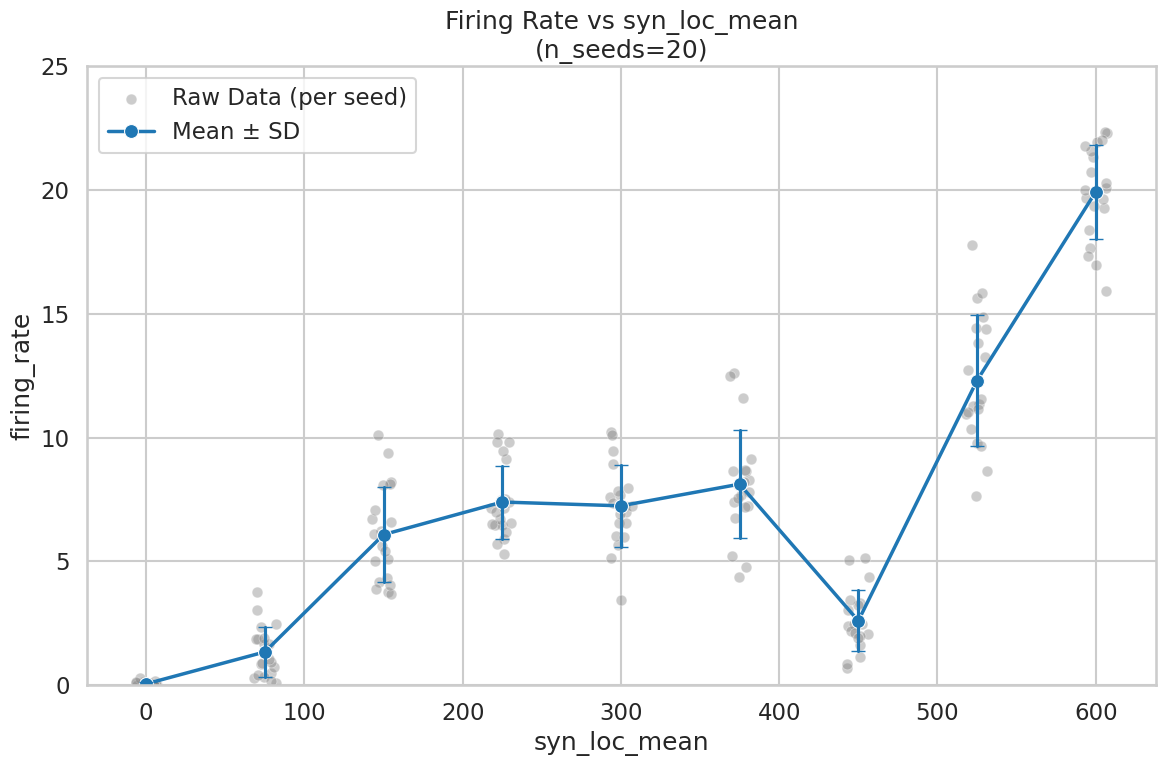

In [3]:
# Baseline Model
df = collect_sweep_results("../multirun/2026-06-02/10-10-52") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 09-52-38
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 180 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


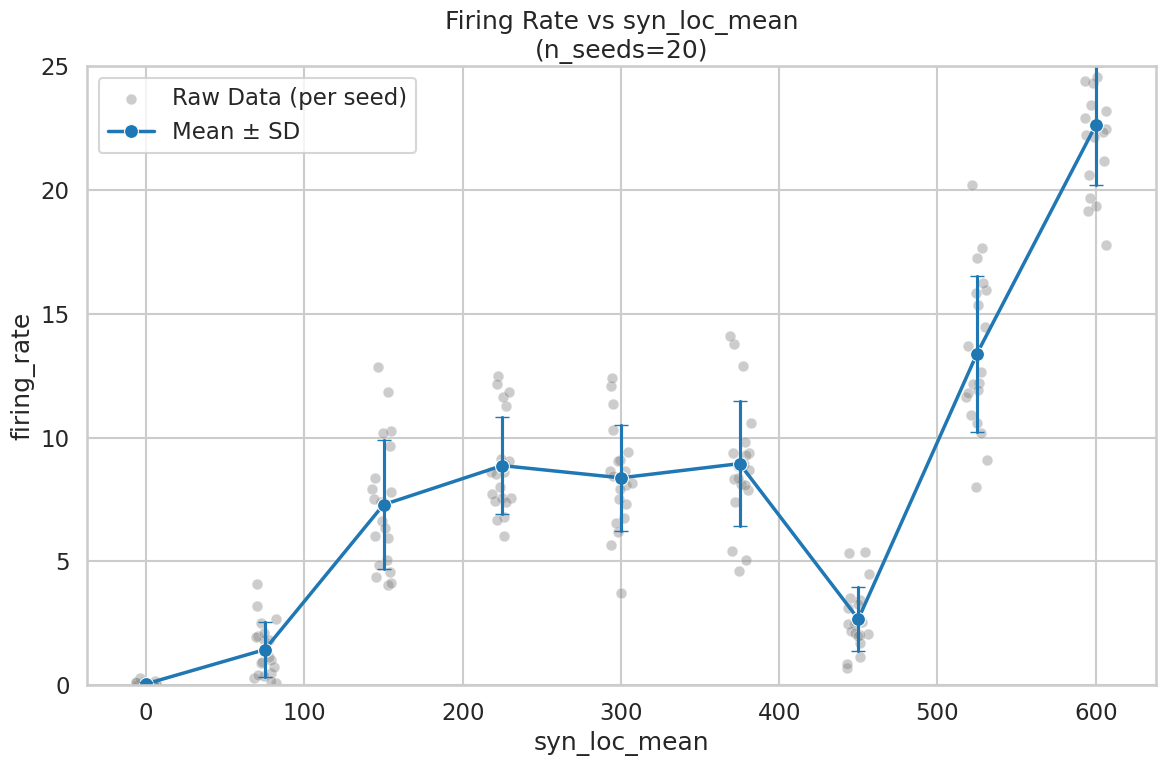

In [4]:
# Ca-L blocked
df = collect_sweep_results("../multirun/2026-06-03/09-52-38") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 12-28-07
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 180 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


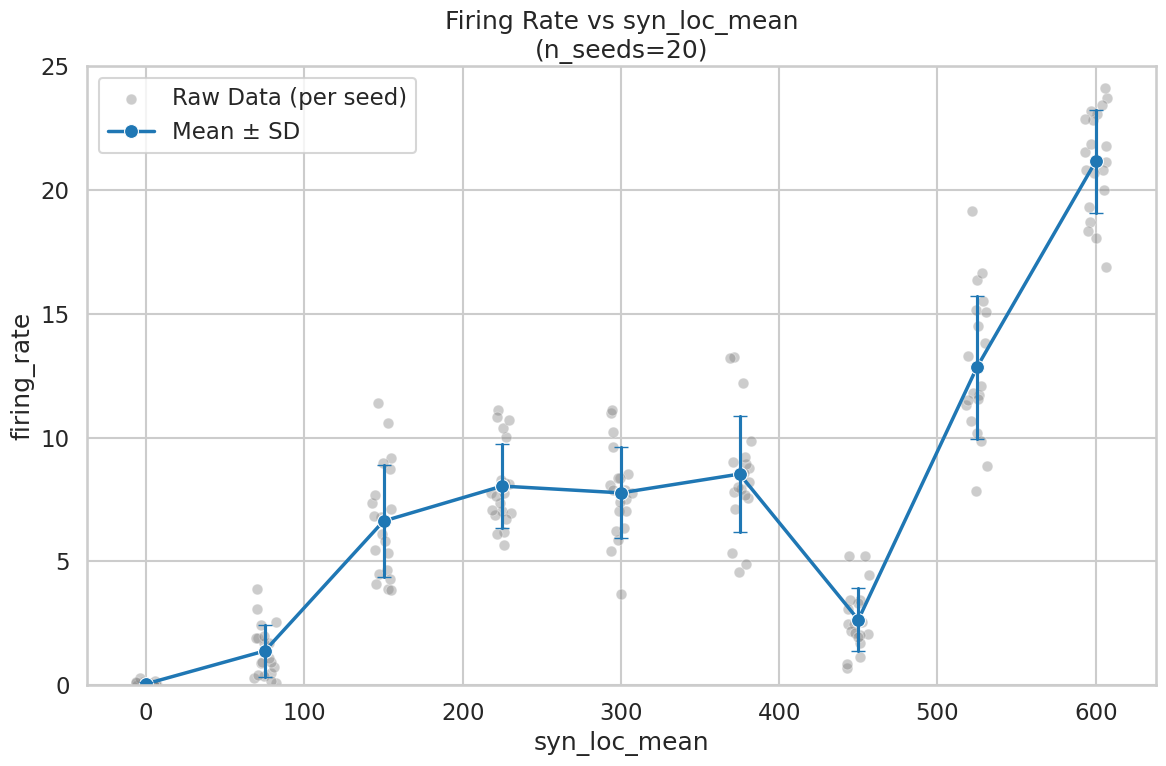

In [5]:
# Ca-N blocked
df = collect_sweep_results("../multirun/2026-06-04/12-28-07") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 03-55-48
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 179 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


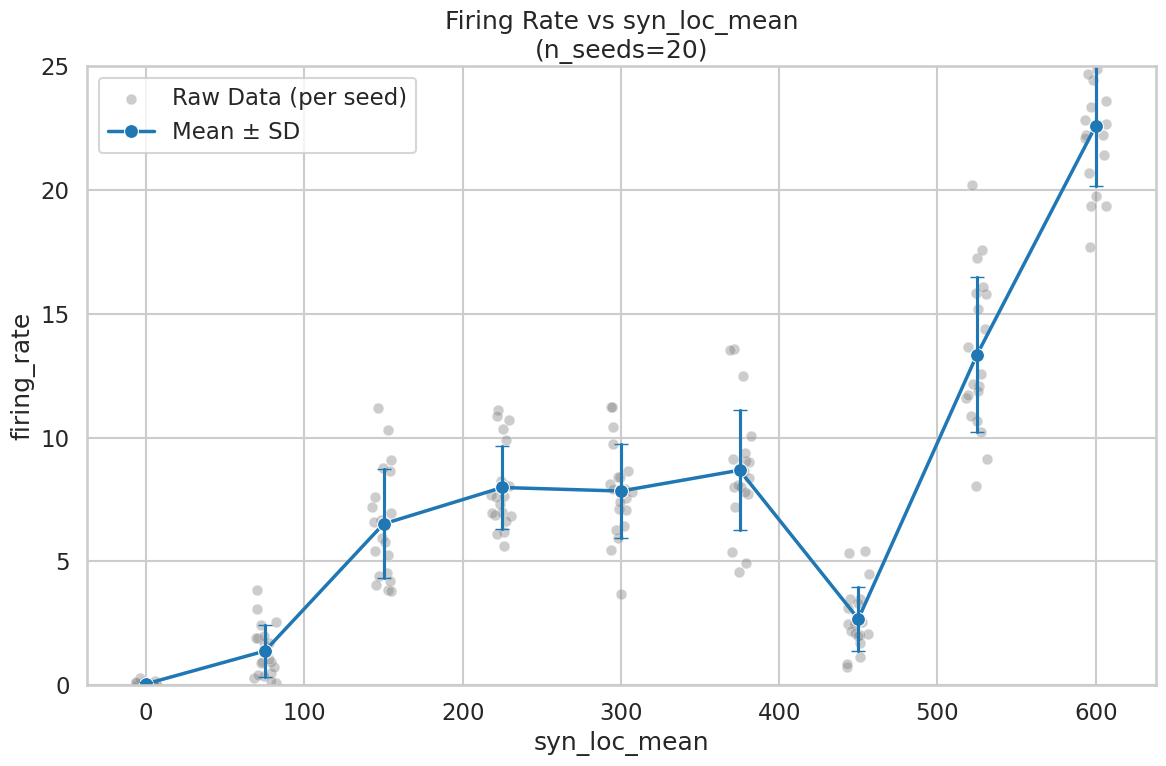

In [6]:
# Ca-T blocked
df = collect_sweep_results("../multirun/2026-06-05/03-55-48") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 17-25-45
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 179 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


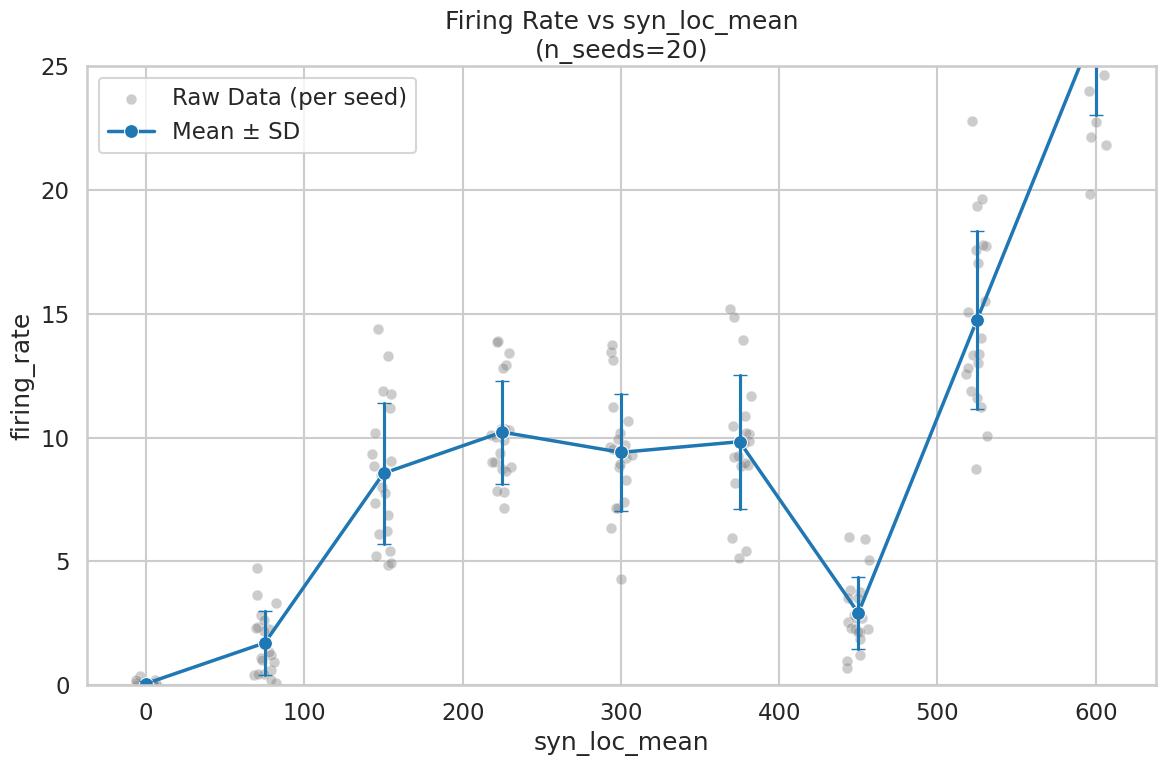

In [7]:
# Ca-depedent K blocked
df = collect_sweep_results("../multirun/2026-06-06/17-25-45") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 16-31-33
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 180 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


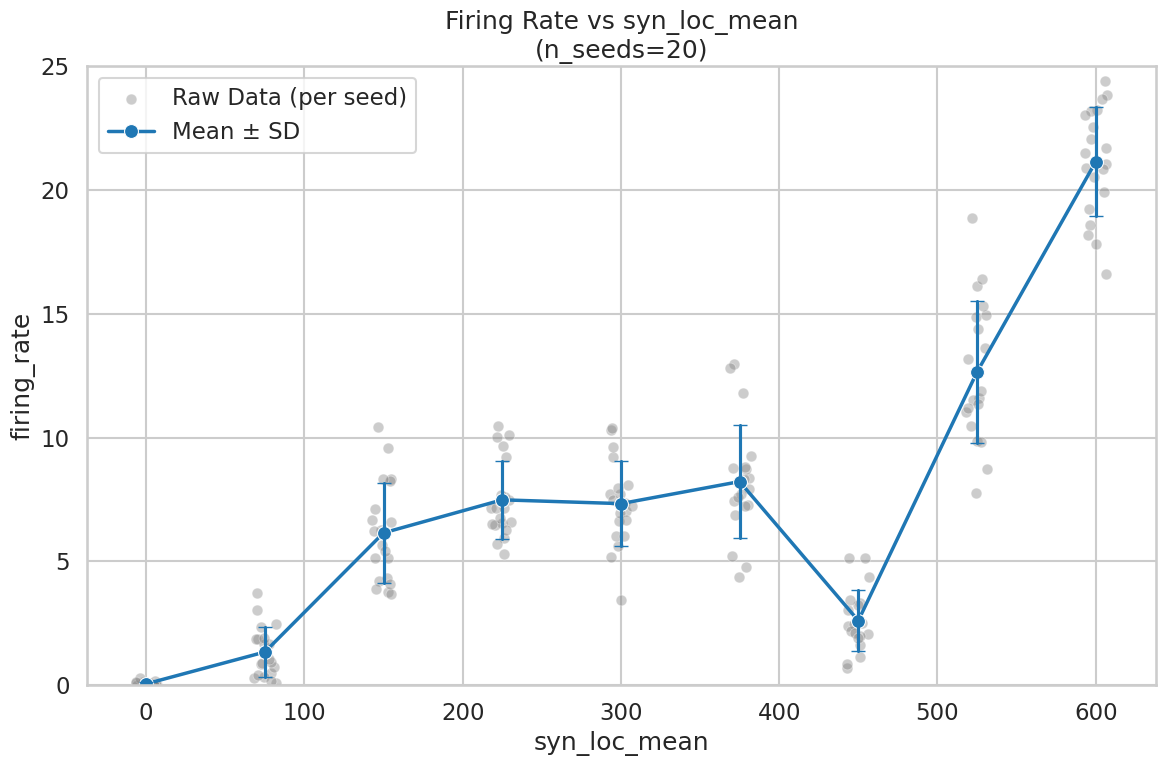

In [8]:
# slwo Ca-depedent K blocked
df = collect_sweep_results("../multirun/2026-06-07/16-31-33") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 15-31-11
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 178 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


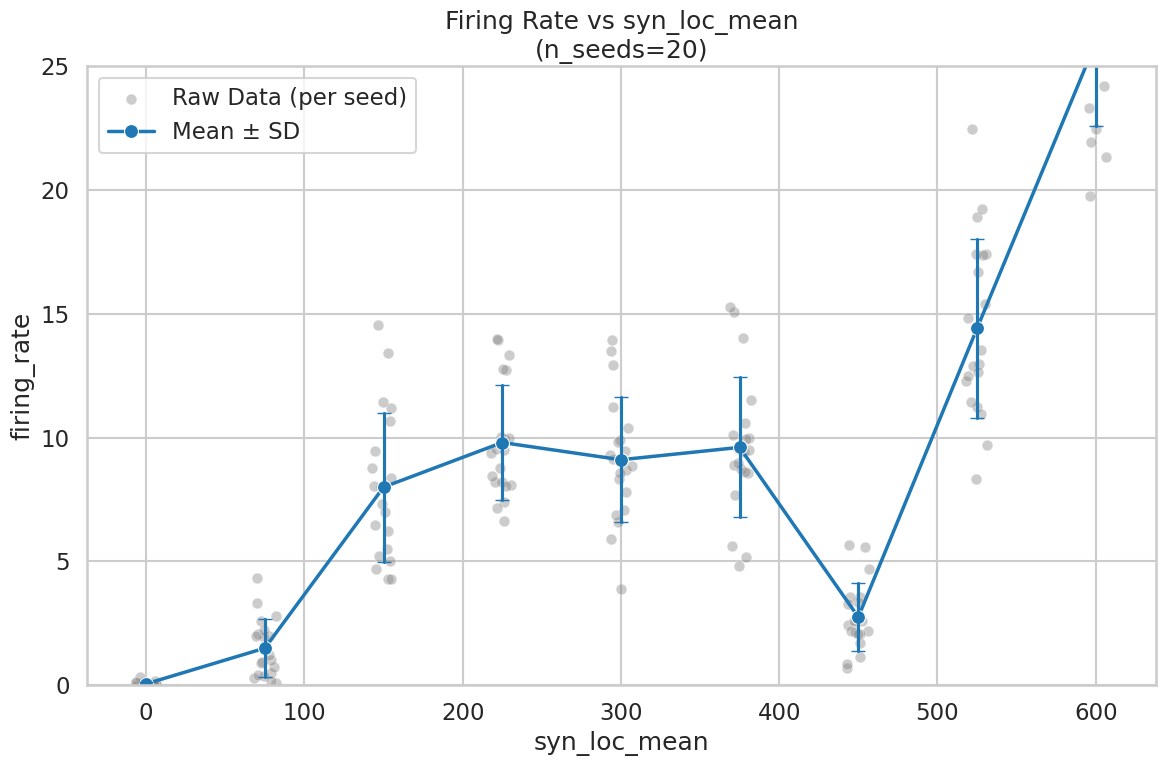

In [9]:
# Ca-L and Ca-T blocked
df = collect_sweep_results("../multirun/2026-06-08/15-31-11") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 12-47-15
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 179 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


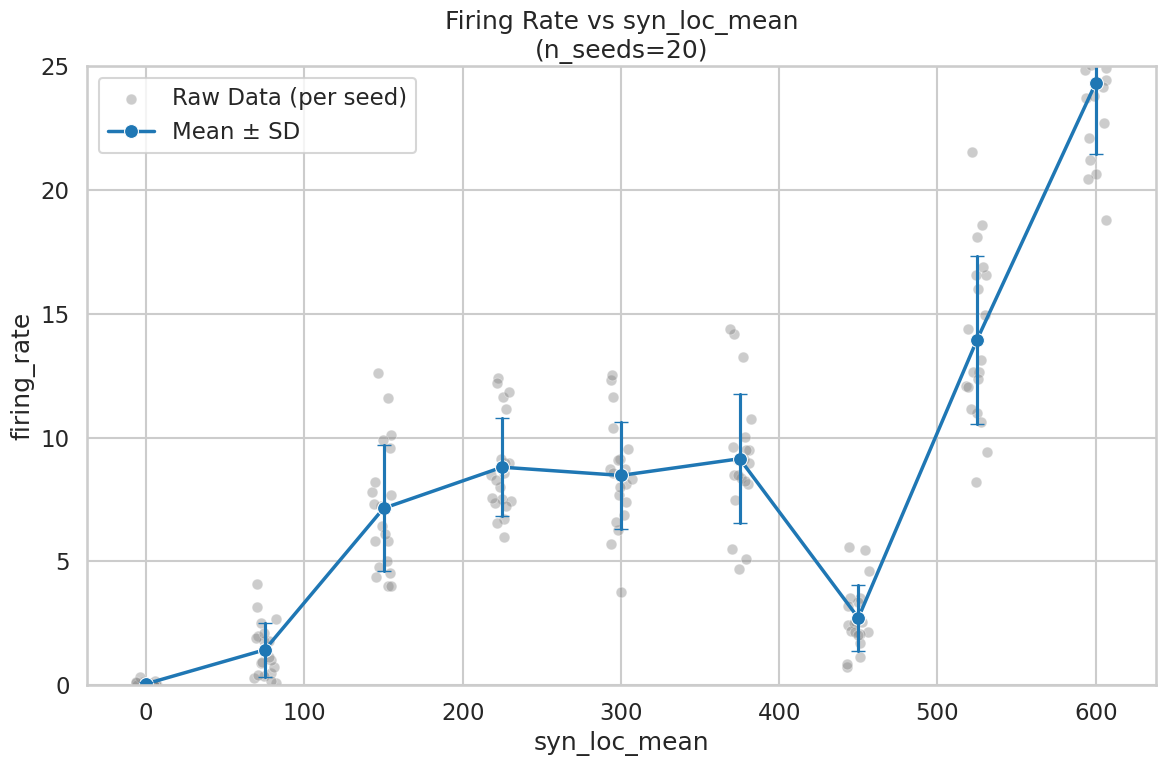

In [10]:
# Ca-N and Ca-T blocked
df = collect_sweep_results("../multirun/2026-06-09/12-47-15") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 04-50-29
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 178 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


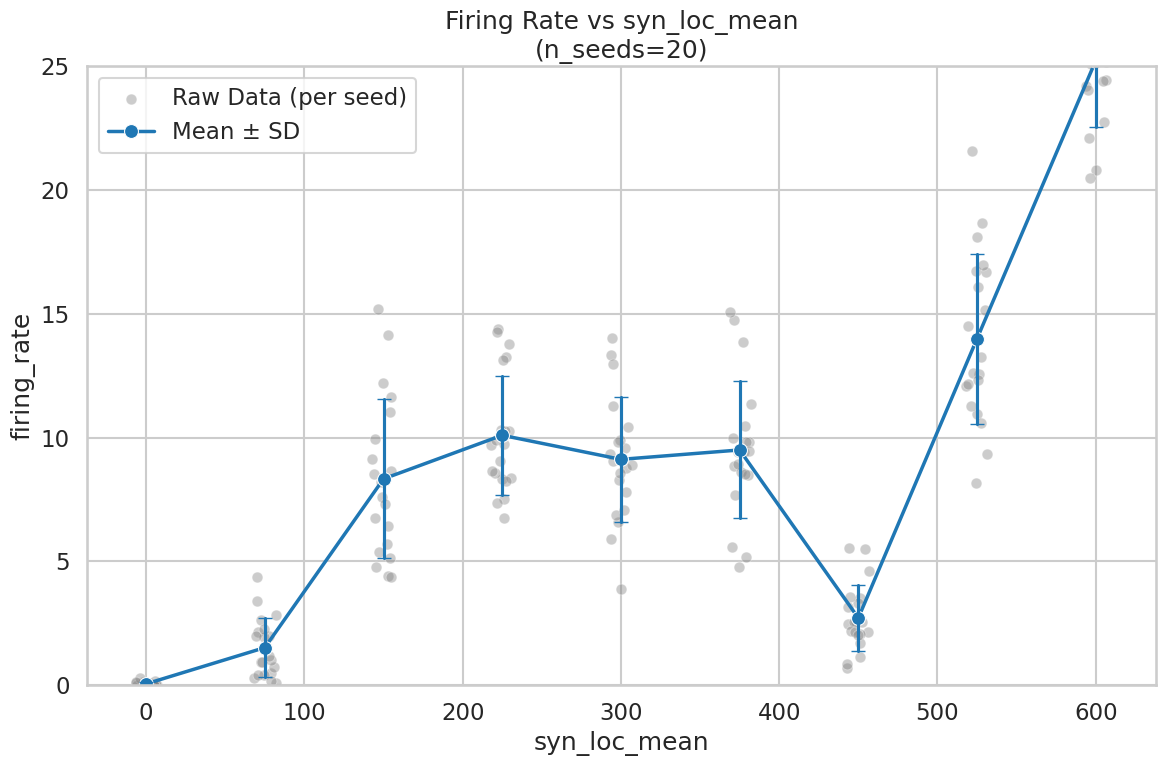

In [11]:
# Ca-N and Ca-L blocked
df = collect_sweep_results("../multirun/2026-06-11/04-50-29") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 18-01-07
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525] (n=8)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 151

Successfully collected 136 / 151 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


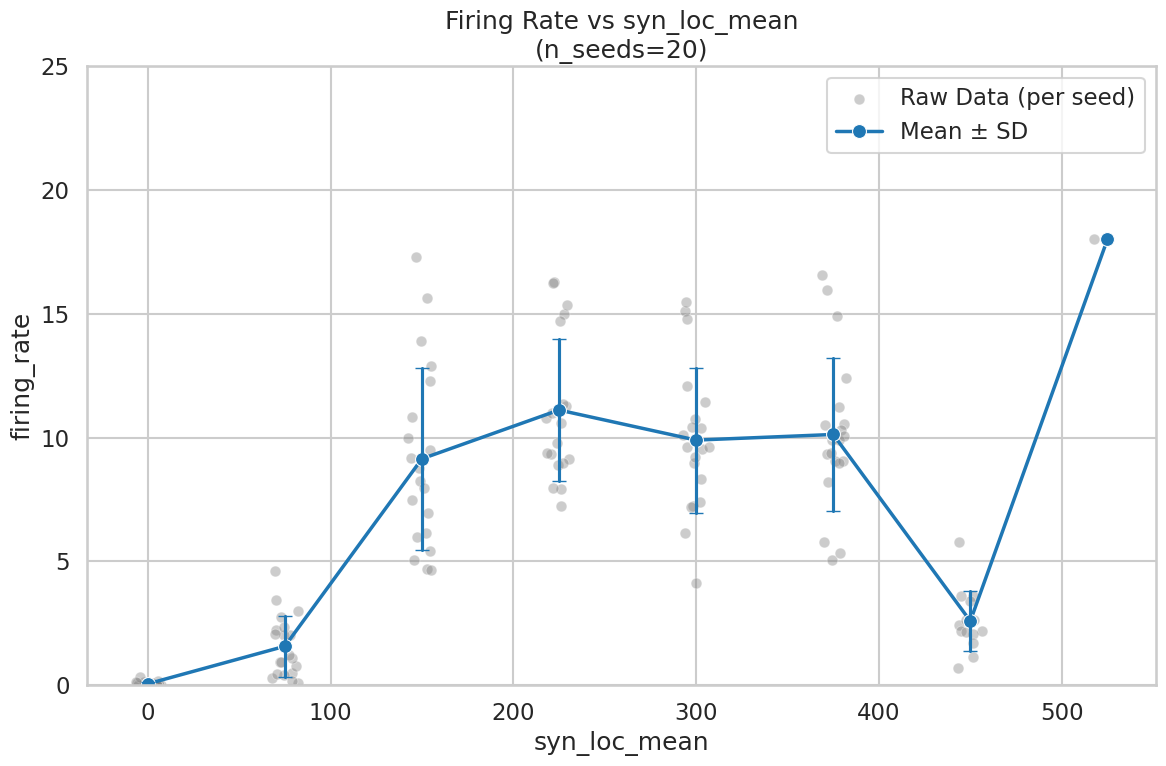

In [12]:
# Ca-N, Ca-T and Ca-L blocked
df = collect_sweep_results("../multirun/2026-06-11/18-01-07") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))

Sweep Summary: 11-09-43
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 180 / 180 results.
Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


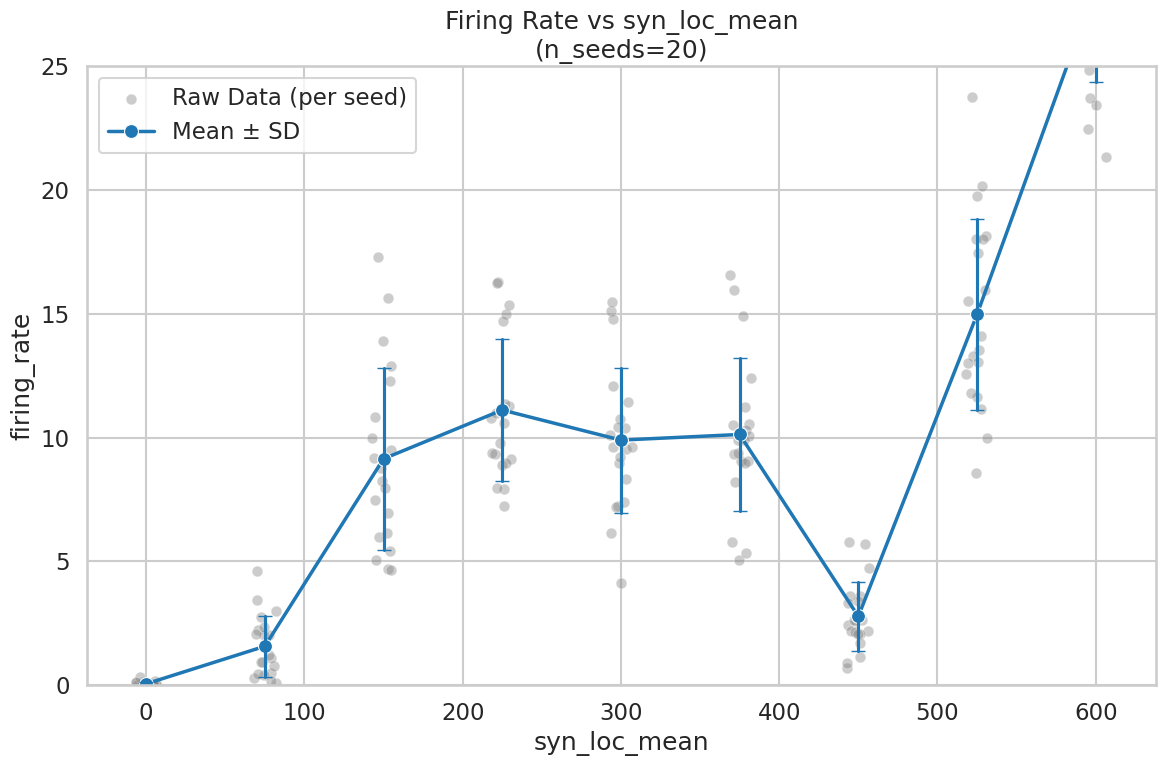

In [13]:
# Ca-N, Ca-L, Ca-T blocked
df = collect_sweep_results("../multirun/2026-06-12/11-09-43") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df, ylim=(0, 25))